In [152]:
import pandas as pd
from database.adatabase import ADatabase
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [153]:
market = ADatabase("market")

In [154]:
queries = []
for band in tqdm([30]):
    for leverage in [5]:
        for stoploss in [.01]:
            queries.append({"band":band,"leverage":leverage,"stoploss":stoploss})

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<?, ?it/s]


In [155]:
for query in tqdm(queries):
    band = query["band"]
    leverage = query["leverage"]
    stoploss = query["stoploss"]
    market.connect()
    df = market.retrieve("xrp_futures")
    market.disconnect()
    df["date"] = [datetime.utcfromtimestamp(int(x)) for x in df["start"]]
    df.sort_values("date",inplace=True)
    df["close"] = [float(x) for x in df["close"]]
    df["rolling"] = df["close"].rolling(band).mean()
    df["upper"] = df["rolling"] + 2 * df["close"].rolling(band).std()
    df["lower"] = df["rolling"] - 2 * df["close"].rolling(band).std()
    df.dropna(inplace=True)
    start = df["date"].min()
    end = df["date"].max()
    # date = start
    state = {
        "buy_price":0,
        "sell_price":0,
        "signal":0,
    }
    states = []
    for date in df["date"].values:
        try:
            current_market = df[df["date"]==date].iloc[0]
            price = current_market["close"].item()
            upper = current_market["upper"].item()
            lower = current_market["lower"].item()
            if price < upper * (1.001) and price > upper * (0.999):
                if state["buy_price"] != 0:
                    state["sell_price"] = price
                    state["sell_time"] = date
                    states.append(state)
                    state = state.copy()
                    state["buy_price"] = 0
                    state["sell_price"] = 0
                else:
                    state = state.copy()
                    state["buy_time"] = date
                    state["buy_price"] = price
                    state["sell_price"] = price
                    state["signal"] = 1
            elif price < lower * (1.001) and price > lower * (0.999):
                if state["buy_price"] != 0:
                    state["sell_price"] = price
                    state["sell_time"] = date
                    states.append(state)
                    state = state.copy()
                    state["buy_price"] = 0
                    state["sell_price"] = 0
                else:
                    state = state.copy()
                    state["buy_time"] = date
                    state["buy_price"] = price
                    state["sell_price"] = price
                    state["signal"] = -1
            else:
                continue
        except Exception as e:
            print(str(e))
    portfolios = pd.DataFrame(states)
    portfolios["return"] = (portfolios["sell_price"] - portfolios["buy_price"]) / portfolios["buy_price"] * portfolios["signal"] * leverage + 1
    portfolios["return"] = [max(x,1-stoploss*leverage) for x in portfolios["return"]]
    portfolios["cr"] = portfolios["return"].cumprod() * 100
    query["cr"] = portfolios["cr"].iloc[-1]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [01:22<00:00, 82.84s/it]


In [156]:
pd.DataFrame(queries).sort_values("cr",ascending=False)

,band,leverage,stoploss,cr
0,30,5,0.01,118.444011


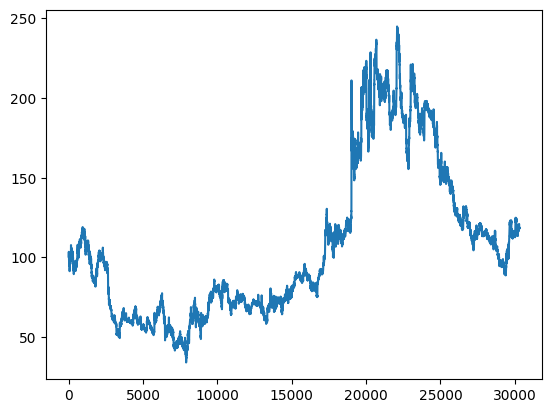

In [157]:
plt.plot(portfolios["cr"])
plt.show()

In [159]:
trades = portfolios[portfolios["return"]!=1]
trades.to_csv("second_option.csv")